In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score
import urllib.request

In [6]:
# classification metrics
def classification_metrics(y_actual, y_pred):
    acc = round(accuracy_score(y_actual, y_pred)*100, 2)
    precision = round(precision_score(y_actual, y_pred)*100, 2)
    recall = round(recall_score(y_actual, y_pred)*100, 2)
    return {"Accuracy":acc, "Precision":precision, "Recall":recall}

In [7]:
# downloading dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
filename = "data/diabetes.csv"

urllib.request.urlretrieve(url, filename)
print("Download complete!")

Download complete!


In [8]:
# loading the dataset
diabetes_df = pd.read_csv("data/diabetes.csv")
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
# class distribution
diabetes_df.Outcome.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [10]:
# splitting the data
X = diabetes_df.drop("Outcome", axis=1)
y = diabetes_df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [11]:
# Logistic regression model pipeline
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
lr_metrics = classification_metrics(y_test, y_pred_lr)

print("Logistic regression metrics")
print("----------------------------")
print(lr_metrics)

Logistic regression metrics
----------------------------
{'Accuracy': 78.57, 'Precision': 78.38, 'Recall': 53.7}


In [12]:
# feature importance
coefficients = lr.named_steps["model"].coef_[0]

for feature, coef in zip(X.columns, coefficients):
    print(f"{feature}: {coef:.4f}")

Pregnancies: 0.4524
Glucose: 1.0755
BloodPressure: -0.2993
SkinThickness: -0.0757
Insulin: -0.0618
BMI: 0.7351
DiabetesPedigreeFunction: 0.4119
Age: 0.1693


In [13]:
# SVM with linear kernel pipeline
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear"))
])

svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
svm_metrics = classification_metrics(y_test, y_pred_svm)
print("SVM (linear kernel) metrics")
print("----------------------------")
print(svm_metrics)

SVM (linear kernel) metrics
----------------------------
{'Accuracy': 77.92, 'Precision': 76.32, 'Recall': 53.7}


In [14]:
# SVM with RBF kernel pipeline
svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf"))
])

svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

rbf_metrics = classification_metrics(y_test, y_pred_rbf)
print("SVM (RBF kernel) metrics")
print("----------------------------")
print(rbf_metrics)

SVM (RBF kernel) metrics
----------------------------
{'Accuracy': 72.08, 'Precision': 65.71, 'Recall': 42.59}


#### Hyperparameter Optimization using Grid Search

In [15]:
# Grid search without pipeline

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Define parameter grid (no model__ prefix)
param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", 0.1, 1]
}

model = SVC()

grid = GridSearchCV(model, param_grid, cv=4, scoring="accuracy")
grid.fit(X_train_scaled, y_train)

# Results
print(f"Best Parameters: {grid.best_params_}")
print(f"Best Score: {round(grid.best_score_, 4)}")

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best Score: 0.7785


In [16]:
# Grid search with pipeline

param_grid = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", 0.1, 1]
}

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC())
])

grid = GridSearchCV(pipe, param_grid, cv=4, scoring="accuracy")
grid.fit(X_train, y_train)

print(f"Best Parameters: {grid.best_params_}")
print(f"Best Score: {round(grid.best_score_, 4)}")

Best Parameters: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Best Score: 0.7785


In [17]:
# using the best-performing model for performance evaluation
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

best_metrics = classification_metrics(y_test, y_pred_best)
print("Best Model metrics")
print("----------------------------")
print(best_metrics)

Best Model metrics
----------------------------
{'Accuracy': 78.57, 'Precision': 78.38, 'Recall': 53.7}


**Exercise**
1. Train a Naive Bayes model on this same data and use GridSearchCV for hyperparameter optimization. How do the results compare to the Logistic regression and SVM models?
2.  Optimize SVM polynomial kernel (degree 2-3) and contrast performance with the RBF and linear kernels.
3.  Perform k-fold cross-validation (k=10) on the original Logistic Regression model and the best SVM model. Plot the mean CV accuracy with standard deviation bands using matplotlib. Which model shows more stable performance across folds?
4.  Engineer a new feature (Insulin/BMI), retrain the best SVM, and assess any improvement with plots.

Qn. 1    
Train a Naive Bayes model on this same data and use GridSearchCV for hyperparameter optimization. How do the results compare to the Logistic regression and SVM models?

In [18]:
#importing the Gaussian Naive Bayes model
from sklearn.naive_bayes import GaussianNB

In [19]:
# creating a pipeline for Gaussian Naive Bayes
nb_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GaussianNB())
])

In [20]:
# defining parameter grid for GaussianNB
param_grid = {
    "model__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
}

In [21]:
#performing grid search for GaussianNB
grid_nb = GridSearchCV(nb_pipe, param_grid, cv=4, scoring="accuracy")
grid_nb.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...aussianNB())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__var_smoothing': [1e-09, 1e-08, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the 

In [22]:
#evaluating the best Naive Bayes model on test data
best_nb = grid_nb.best_estimator_
y_pred_nb = best_nb.predict(X_test)

nb_metrics = classification_metrics(y_test, y_pred_nb)
print("Naive Bayes metrics")
print("------------------")
print(nb_metrics)

Naive Bayes metrics
------------------
{'Accuracy': 70.78, 'Precision': 60.0, 'Recall': 50.0}


Comparison of the results

| Model                  | Accuracy (%) | Precision (%) | Recall (%) |
|------------------------|-------------|---------------|------------|
| Logistic Regression    | 78.57       | 78.38         | 53.7       |
| SVM (linear kernel)    | 77.92       | 76.32         | 53.7       |
| SVM (RBF kernel)       | 72.08       | 65.71         | 42.59      |
| Naive Bayes            | 70.78       | 60.0          | 50.0       |

Row Analysis  

Logistic Regression                                      
        Accuracy: 78.57% == highest among all models.                                                        
        Precision: 78.38% == best at avoiding false positives.                                                       
        Recall: 53.7% == moderate, meaning it captures a little more than half of true positives.                                        
        Interpretation: Logistic Regression performs best overall and is well-balanced.                                                    

SVM (linear kernel)                                         
        Accuracy: 77.92% == very close to Logistic Regression.                       
        Precision: 76.32% == slightly lower than Logistic Regression.                        
        Recall: 53.7% == same as Logistic Regression.                            
       
SVM (RBF kernel)                                                
        Accuracy: 72.08% == lower than linear models.                                                    
        Precision: 65.71% == more false positives than linear models.                                    
        Recall: 42.59% == misses more actual positives.                                              
        
Naive Bayes                                                         
        Accuracy: 70.78% == lowest overall.                                         
        Precision: 60.0% == less reliable in predicting positives.                                          
        Recall: 50.0% == detects only half of actual positives.                                 
        Interpretation: Naive Bayes assumes features are independent, but in this dataset, features like Glucose, BMI, Age are correlated hence model performs worse.                                           

Best overall model: Logistic Regression (high accuracy + precision, decent recall)

Qn.2                                                                        
Optimize SVM polynomial kernel (degree 2-3) and contrast performance with the RBF and linear kernels.

In [23]:
#defining SVM with polynomial kernel pipeline
poly_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC())
])

In [24]:
#defining parameter grid for polynomial kernel SVM
param_grid_poly = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["poly"],
    "model__degree": [2, 3],
    "model__gamma": ["scale", 0.1, 1],
    "model__coef0": [0.0, 0.1, 0.5]
}

In [25]:
#performing grid search for polynomial kernel SVM
grid_poly = GridSearchCV(poly_pipe, param_grid_poly, cv=4, scoring="accuracy")
grid_poly.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...del', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.1, 1, ...], 'model__coef0': [0.0, 0.1, ...], 'model__degree': [2, 3], 'model__gamma': ['scale', 0.1, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold

In [ ]:
#evaluating the best polynomial kernel SVM model on test data
best_poly = grid_poly.best_estimator_
y_pred_poly = best_poly.predict(X_test)

poly_metrics = classification_metrics(y_test, y_pred_poly)
print("SVM (Polynomial kernel) metrics")
print("-------------------------------")
print(poly_metrics)
print("Best Parameters:", grid_poly.best_params_)

SVM (Polynomial kernel) metrics
-------------------------------
{'Accuracy': 75.97, 'Precision': 77.42, 'Recall': 44.44}
Best Parameters: {'model__C': 0.1, 'model__coef0': 0.5, 'model__degree': 2, 'model__gamma': 0.1, 'model__kernel': 'poly'}


Comparison of the results

| Model                        | Accuracy (%) | Precision (%) | Recall (%) |
|-------------------------------|-------------|---------------|------------|
| SVM (linear kernel)           | 77.92       | 76.32         | 53.7       |
| SVM (RBF kernel)              | 72.08       | 65.71         | 42.59      |
| SVM (Polynomial kernel, degree 2) | 75.97    | 77.42         | 44.44      |

Contrast Analysis

Accuracy                      
Linear SVM: highest accuracy (77.92%) == highest accuracy               
Polynomial SVM: slightly lower accuracy (75.97%)                                           
RBF SVM: lowest accuracy (72.08%)                                   

Precision                                             
Polynomial SVM: highest precision (77.42%) == predicts positives more reliably                                
Linear SVM: slightly lower (76.32%)                                             
RBF SVM: lowest (65.71%) → more false positives                                                            

Recall                        
Linear SVM: highest recall (53.7%) == captures more actual positives                         
Polynomial SVM: lower recall (44.44%) → misses more positives                    
RBF SVM: lowest recall (42.59%)                                  

Qn.3

Perform k-fold cross-validation (k=10) on the original Logistic Regression model and the best SVM model. Plot the mean CV accuracy with standard deviation bands using matplotlib. Which model shows more stable performance across folds?

In [27]:
from sklearn.model_selection import cross_val_score

In [28]:
#performing cross-validation for logistic regression and best SVM model
k = 10

# Logistic Regression
cv_scores_lr = cross_val_score(lr, X, y, cv=k, scoring="accuracy")

# Best SVM model (already tuned)
cv_scores_svm = cross_val_score(best_model, X, y, cv=k, scoring="accuracy")

In [29]:
#computing mean and standard deviation of cross-validation scores
# Logistic Regression
mean_lr = np.mean(cv_scores_lr)
std_lr = np.std(cv_scores_lr)

# SVM
mean_svm = np.mean(cv_scores_svm)
std_svm = np.std(cv_scores_svm)

print("Logistic Regression: Mean Accuracy = {:.4f}, Std = {:.4f}".format(mean_lr, std_lr))
print("Best SVM: Mean Accuracy = {:.4f}, Std = {:.4f}".format(mean_svm, std_svm))

Logistic Regression: Mean Accuracy = 0.7722, Std = 0.0362
Best SVM: Mean Accuracy = 0.7696, Std = 0.0322


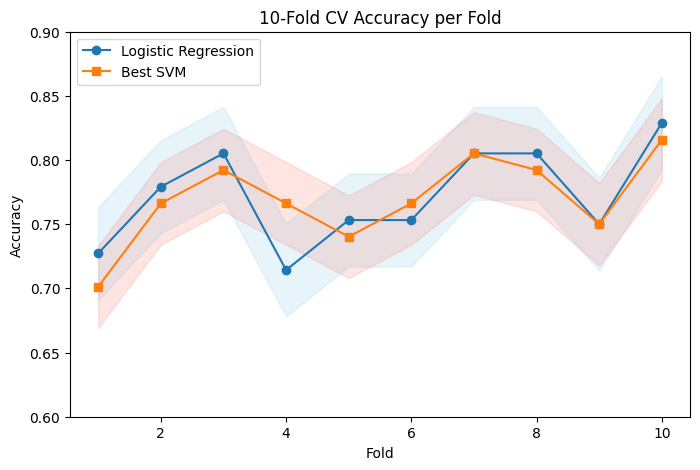

In [ ]:
#visualizing cross-validation scores for each fold
folds = np.arange(1, 11)

plt.figure(figsize=(8,5))
plt.plot(folds, cv_scores_lr, marker='o', label='Logistic Regression')
plt.plot(folds, cv_scores_svm, marker='s', label='Best SVM')
plt.fill_between(folds, cv_scores_lr - std_lr, cv_scores_lr + std_lr, color='skyblue', alpha=0.2)
plt.fill_between(folds, cv_scores_svm - std_svm, cv_scores_svm + std_svm, color='salmon', alpha=0.2)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("10-Fold CV Accuracy per Fold")
plt.legend()
plt.ylim(0.6, 0.9)
plt.show()

The best SVM model shows slightly more stable performance across folds because its standard deviation is smaller

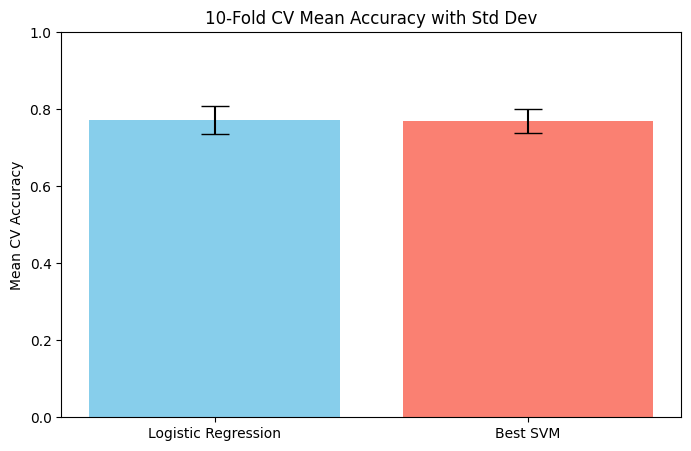

In [31]:
#plotting mean accuracy with error bars for standard deviation
means = [mean_lr, mean_svm]
stds = [std_lr, std_svm]
models = ['Logistic Regression', 'Best SVM']
plt.figure(figsize=(8,5))
plt.bar(models, means, yerr=stds, capsize=10, color=['skyblue', 'salmon'])
plt.ylabel("Mean CV Accuracy")
plt.title("10-Fold CV Mean Accuracy with Std Dev")
plt.ylim(0, 1)
plt.show()

Qn.4

Engineer a new feature (Insulin/BMI), retrain the best SVM, and assess any improvement with plots.

In [32]:
#Avoiding division by zero by replacing zero BMI with a small number
X['Insulin_BMI'] = X['Insulin'] / X['BMI'].replace(0, 1e-6)

#updating train-test split with new feature
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

In [33]:
#using the same pipeline as before for polynomial kernel SVM with the new feature
best_poly_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel=grid_poly.best_params_['model__kernel'],
        C=grid_poly.best_params_['model__C'],
        degree=grid_poly.best_params_['model__degree'],
        gamma=grid_poly.best_params_['model__gamma'],
        coef0=grid_poly.best_params_['model__coef0']
    ))
])

In [34]:
#fitting the best polynomial kernel SVM model with the new feature
best_poly_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",2
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1


In [35]:
#predicting with the updated polynomial kernel SVM model
y_pred_poly_new = best_poly_pipe.predict(X_test)

In [36]:
#computing metrics for the updated polynomial kernel SVM model
poly_metrics_new = classification_metrics(y_test, y_pred_poly_new)
print("Polynomial SVM metrics with Insulin/BMI feature")
print("------------------------------------------------")
print(poly_metrics_new)

Polynomial SVM metrics with Insulin/BMI feature
------------------------------------------------
{'Accuracy': 75.97, 'Precision': 77.42, 'Recall': 44.44}


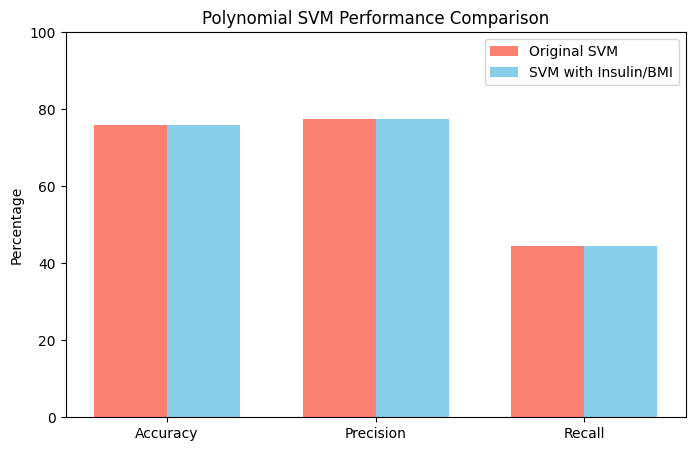

In [37]:
#visualizing the performance comparison between original and updated polynomial kernel SVM models
metrics_names = list(poly_metrics.keys())
old_metrics = list(poly_metrics.values())
new_metrics = list(poly_metrics_new.values())

x = np.arange(len(metrics_names))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, old_metrics, width, label='Original SVM', color='salmon')
plt.bar(x + width/2, new_metrics, width, label='SVM with Insulin/BMI', color='skyblue')
plt.xticks(x, metrics_names)
plt.ylabel("Percentage")
plt.title("Polynomial SVM Performance Comparison")
plt.ylim(0, 100)
plt.legend()
plt.show()

This plot clearly shows the engineered feature did not change model performance.